<a href="https://www.kaggle.com/code/mykolarekunenko/notebook-hw-2?scriptVersionId=293474283" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Завдання:
Ознайомитись з даними та структурою даних
Створіть доповнення(transform) для тренувальних та тестових даних. посилання
Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)
Переконайтесь що у вас привильні назви класів
Створіть DataLoader для тренувальних та тестових даних
Візуалізуйте дані
Збережіть kaggle notebook для подальшої роботи

In [11]:
import torch  
from torchvision import datasets, transforms 

In [12]:
data_dir = "/kaggle/input/fruit-recognition/train/train"
# Створюємо екземпляр ImageFolder
dataset = datasets.ImageFolder(data_dir)

In [13]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [14]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [15]:
img, label = data_train[200]

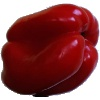

In [16]:
img

In [17]:
len(dataset), len(data_train), len(data_test)

(16854, 13484, 3370)

In [18]:
train_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.RandomRotation(180),
     transforms.RandomHorizontalFlip(p=0.5),
     transforms.RandomVerticalFlip(p=0.5),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
     transforms.ToTensor()
    ] 
)

In [19]:
train_transform(img).shape

torch.Size([3, 64, 64])

In [20]:
test_transform(img).shape

torch.Size([3, 64, 64])

In [21]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [22]:
train_data = TransformDataset(data_train, train_transform)
test_data = TransformDataset(data_test, test_transform)

In [23]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [24]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape)

torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([42, 3, 64, 64])
torch.Size([42])


(64, 64, 3)


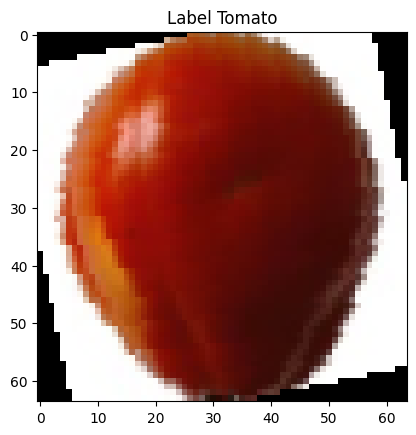

(64, 64, 3)


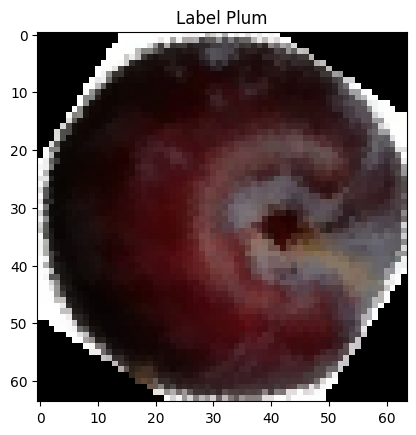

(64, 64, 3)


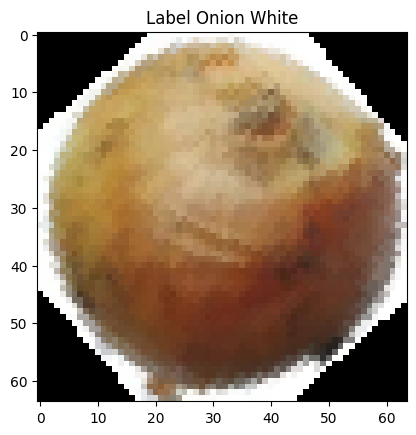

In [25]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

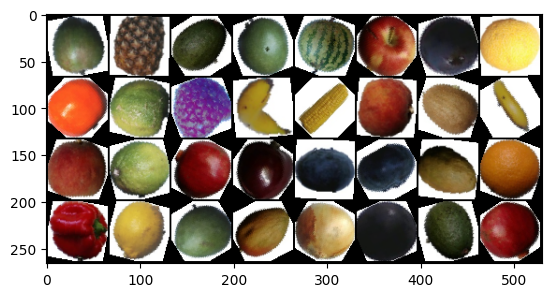

In [26]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [27]:
img, label = train_data[0]

img.shape

torch.Size([3, 64, 64])

In [28]:
3*64*64

12288

In [29]:
len(dataset.classes)

33

In [3]:
from torch import nn

#нейромережа
model = nn.Sequential(
    nn.Flatten(),   # переведе зображення 3х64х64 в нейрони 12288
    nn.Linear(12288, 128),   # на вході 12288 нейронів передає інформацію 64 нейронам
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 33)   # 33 нейрона на кожен тип фрукта
)


# підключення до процесора
device = 'cuda'
model = model.to(device)

In [32]:
img = img.unsqueeze(0).to(device)
result = model(img)
result

tensor([[ 0.1614, -0.0891, -0.0765,  0.0194, -0.0605,  0.0393,  0.1853, -0.0254,
          0.1475,  0.0384, -0.1841, -0.1448,  0.1589,  0.0290,  0.1193,  0.0405,
          0.1229,  0.0055, -0.0665,  0.0804, -0.1508, -0.0417,  0.0828,  0.1458,
         -0.0395,  0.0943, -0.0085, -0.0474,  0.0037, -0.0129,  0.1285, -0.0229,
          0.0542]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [33]:
#ймовірності
probs = nn.Softmax()(result)
probs

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[0.0347, 0.0270, 0.0274, 0.0301, 0.0278, 0.0307, 0.0356, 0.0288, 0.0342,
         0.0307, 0.0246, 0.0256, 0.0346, 0.0304, 0.0333, 0.0308, 0.0334, 0.0297,
         0.0276, 0.0320, 0.0254, 0.0283, 0.0321, 0.0342, 0.0284, 0.0325, 0.0293,
         0.0282, 0.0297, 0.0292, 0.0336, 0.0289, 0.0312]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)

In [34]:
label

31

**# Визначення функції втрат та оптимізатора**

In [35]:
# Функція втрат для класифікації
loss_fn = nn.CrossEntropyLoss()

# Оптимізатор (Adam) для оновлення ваг моделі
optimizer = torch.optim.Adam(
    model.parameters(),   # параметри нефромережі
    lr=0.001
)

In [36]:
for t in range(10):
    # один крок навчання
    total_loss = 0

    # рухаємось по пакетах даних
    for imgs, labels in train_loader:
        # підключити до device
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        # застосовую нейромережу
        prediction = model(imgs)

        # рахуємо помилку(loss)
        loss = loss_fn(prediction, labels)

        # градієнтний спуск
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.cpu().item()

    print(total_loss)

115.55299508571625
42.143923819065094
26.115710884332657
19.808595418930054
16.31707639992237
13.808108404278755
12.103969246149063
10.736612528562546
9.528080597519875
8.910734117031097


In [37]:
labels

tensor([13,  7, 12,  8, 20, 12, 18, 31, 31,  2,  2, 20,  6, 29, 32, 14,  6,  2,
        31, 26, 28, 12, 11, 17, 25, 26, 18, 11, 18,  7, 24,  6,  1, 14, 14, 30,
        24, 32, 12, 11, 22, 18, 29, 19, 23, 28, 31,  9, 20,  0, 15, 22,  8, 26,
         7, 15, 23,  5,  0, 22, 31, 30,  5,  0, 32,  5, 16, 22, 27, 19, 20, 30,
        32, 26,  7,  3,  8, 25, 26, 29, 10, 18, 19, 14, 16,  1,  7,  0, 28, 27,
        18, 16, 18, 23, 29, 24, 25,  8, 22, 12,  4, 14,  0, 23,  6,  9, 13,  1,
        16, 30, 19, 24,  5,  7,  1, 15,  2, 29, 28, 27, 30,  3,  4, 30, 24, 21,
        25, 25,  8,  8,  8, 31, 28, 27,  4,  0, 30, 32, 16,  3, 12,  5, 19, 24,
         7, 20, 31, 14, 10,  7, 10,  3,  2, 25,  3, 14, 32, 30, 13, 12, 13,  2,
         1, 32, 12, 22,  6, 18,  3,  7, 19, 18], device='cuda:0')

In [38]:
nn.Softmax()(prediction)

tensor([[2.0668e-08, 1.0217e-05, 2.9063e-12,  ..., 5.7258e-05, 6.2753e-16,
         6.1189e-08],
        [5.9500e-13, 5.8914e-08, 1.7060e-13,  ..., 3.1722e-24, 1.7020e-24,
         5.7736e-24],
        [1.5664e-12, 3.2203e-13, 8.7423e-20,  ..., 1.0774e-08, 1.0553e-20,
         1.1746e-07],
        ...,
        [1.1045e-13, 1.7761e-08, 1.5122e-16,  ..., 6.3485e-23, 1.6887e-26,
         3.0656e-22],
        [9.3904e-12, 2.1756e-03, 9.3799e-09,  ..., 9.4600e-04, 4.4513e-13,
         3.7774e-07],
        [7.2734e-09, 1.2927e-14, 1.9986e-02,  ..., 5.0360e-18, 1.0728e-07,
         8.6911e-34]], device='cuda:0', grad_fn=<SoftmaxBackward0>)